# 01 Data preparation and EDA

This notebook prepares `Turismy/reviews_enriched.csv` from the original dataset and creates the core exploratory analysis figures used in the project report.

In [1]:
from pathlib import Path
import sys

_PROJECT_MARKERS = (
    Path('src') / 'data' / 'prepare_dataset.py',
    Path('Turismy') / 'reviews.csv',
)


def _is_project_root(path):
    return all((path / marker).exists() for marker in _PROJECT_MARKERS)


def _candidate_roots(start):
    start = start.resolve()
    seen = set()

    for candidate in (start, *start.parents):
        if candidate not in seen:
            seen.add(candidate)
            yield candidate

    for base in (start, start.parent):
        try:
            children = list(base.iterdir())
        except OSError:
            continue

        for child in children:
            try:
                if not child.is_dir():
                    continue
                candidate = child.resolve()
            except OSError:
                continue

            if candidate not in seen:
                seen.add(candidate)
                yield candidate


def find_project_root():
    for candidate in _candidate_roots(Path.cwd()):
        if _is_project_root(candidate):
            return candidate

    raise RuntimeError(
        'Project root was not found. Start the notebook from the repository root, '
        'the notebooks folder, or the parent folder that contains MasinskoUcenje-Projekat.'
    )


PROJECT_ROOT = find_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.data.prepare_dataset import prepare_dataset, LABEL_COLUMNS

figures_dir = PROJECT_ROOT / 'artifacts' / 'figures'
figures_dir.mkdir(parents=True, exist_ok=True)

In [2]:
df = prepare_dataset()
df.shape, df.head(3)

((9964, 8),
    Index                                           comments  cleanliness  \
 0      0  Daniel is really cool. The place was nice and ...            1   
 1      1  If you want the authentic Amsterdam houseboat ...            1   
 2      2  Unique and luxurious to be sure. I couldn't re...            1   
 
    location  luxury  family_friendly  \
 0         1       0                0   
 1         1       1                0   
 2         1       1                0   
 
                                       clean_comments  visitor_rating  
 0  Daniel is really cool. The place was nice and ...             4.2  
 1  If you want the authentic Amsterdam houseboat ...             4.6  
 2  Unique and luxurious to be sure. I couldn't re...             4.7  )

In [3]:
df[['clean_comments', *LABEL_COLUMNS, 'visitor_rating']].describe(include='all')

,clean_comments,cleanliness,location,luxury,family_friendly,visitor_rating
count,9964,9964.000000,9964.000000,9964.000000,9964.000000,9964.000000
unique,9964,NaN,NaN,NaN,NaN,NaN
top,Daniel is really cool. The place was nice and ...,NaN,NaN,NaN,NaN,NaN
freq,1,NaN,NaN,NaN,NaN,NaN
mean,NaN,0.266459,0.593537,0.297270,0.041449,3.753944
std,NaN,0.442129,0.491198,0.457079,0.199337,0.412912
min,NaN,0.000000,0.000000,0.000000,0.000000,2.800000
25%,NaN,0.000000,0.000000,0.000000,0.000000,3.400000
50%,NaN,0.000000,1.000000,0.000000,0.000000,3.700000
75%,NaN,1.000000,1.000000,1.000000,0.000000,4.000000


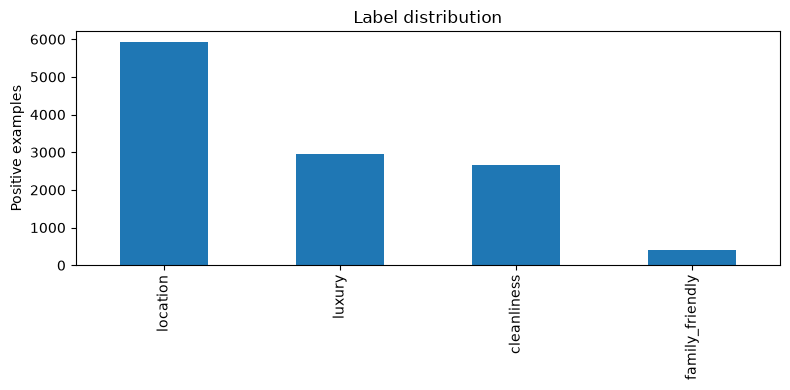

In [4]:
label_counts = df[list(LABEL_COLUMNS)].sum().sort_values(ascending=False)
ax = label_counts.plot(kind='bar', figsize=(8, 4), title='Label distribution')
ax.set_ylabel('Positive examples')
plt.tight_layout()
plt.savefig(figures_dir / 'label-distribution.png', dpi=150)
plt.show()

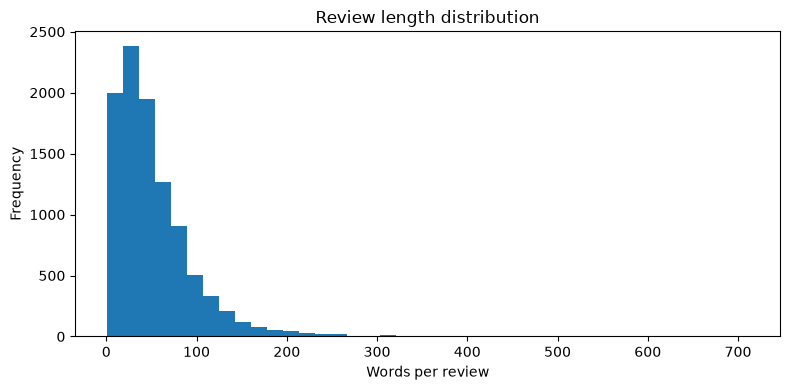

In [5]:
word_lengths = df['clean_comments'].str.split().str.len()
ax = word_lengths.plot(kind='hist', bins=40, figsize=(8, 4), title='Review length distribution')
ax.set_xlabel('Words per review')
plt.tight_layout()
plt.savefig(figures_dir / 'review-length-distribution.png', dpi=150)
plt.show()

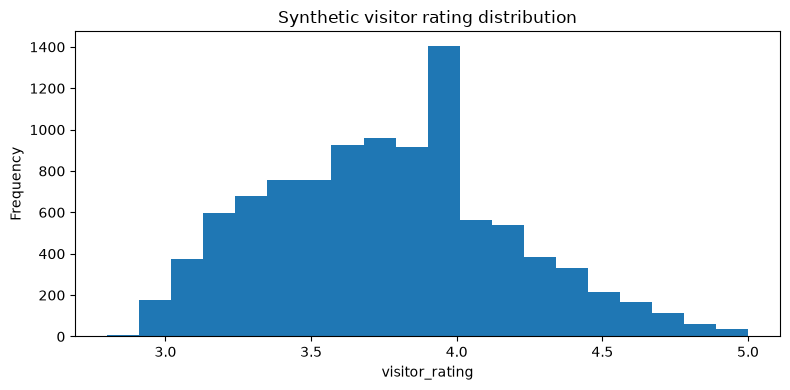

In [6]:
ax = df['visitor_rating'].plot(kind='hist', bins=20, figsize=(8, 4), title='Synthetic visitor rating distribution')
ax.set_xlabel('visitor_rating')
plt.tight_layout()
plt.savefig(figures_dir / 'visitor-rating-distribution.png', dpi=150)
plt.show()

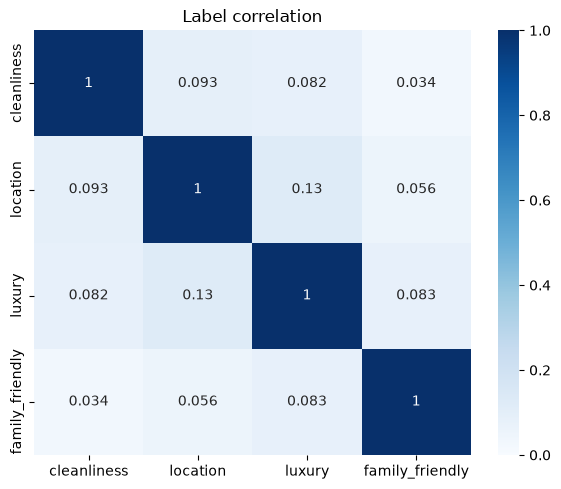

In [7]:
plt.figure(figsize=(6, 5))
sns.heatmap(df[list(LABEL_COLUMNS)].corr(), annot=True, cmap='Blues', vmin=0, vmax=1)
plt.title('Label correlation')
plt.tight_layout()
plt.savefig(figures_dir / 'label-correlation.png', dpi=150)
plt.show()